# Rae2822 2D Wing Slice Model

### Import Library

In [132]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

### Loading Data

In [93]:
angles = range(21)

folder_path = "./data/rae2822/angvar_sa/"

files = sorted(glob.glob(f"{folder_path}*/surface_flow.csv"))

master_df = []

for i, filename in enumerate(files):
    df = pd.read_csv(filename)

    # apply angles for each case
    df['AoA'] = angles[i]

    master_df.append(df)

# Combine into one training set
full_data = pd.concat(master_df, ignore_index=True)

In [94]:
print(f"Total rows: {len(full_data)}")
full_data.head()

Total rows: 4032


,PointID,x,y,Density,Momentum_x,Momentum_y,Energy,Nu_Tilde,Pressure,Temperature,Mach,Pressure_Coefficient,Laminar_Viscosity,Skin_Friction_Coefficient_x,Skin_Friction_Coefficient_y,Heat_Flux,Y_Plus,Eddy_Viscosity,AoA
0,25,0.985397,0.000943,0.467747,0.0,0.0,106411.802258,0.0,42564.720903,317.006918,0.0,0.262408,0.000019,0.002042,-8.852195e-05,-175.102208,2.161991,0.0,0
1,51,0.969573,0.001489,0.470406,0.0,0.0,107034.099699,0.0,42813.639880,317.058955,0.0,0.279663,0.000019,0.001661,-3.739569e-05,-75.599800,1.954830,0.0,0
2,77,0.952680,0.001679,0.472434,0.0,0.0,107515.203056,0.0,43006.081222,317.116347,0.0,0.293002,0.000019,0.001458,-9.411266e-07,-43.903973,1.834732,0.0,0
3,103,0.934996,0.001511,0.472826,0.0,0.0,107615.419162,0.0,43046.167665,317.149233,0.0,0.295781,0.000019,0.001345,2.838548e-05,-31.992952,1.763323,0.0,0
4,129,0.916822,0.000923,0.472299,0.0,0.0,107499.088533,0.0,42999.635413,317.159465,0.0,0.292556,0.000019,0.001284,5.265905e-05,-27.650354,1.722190,0.0,0


Text(0.5, 1.0, 'Sample Case: AoA = 0.0°')

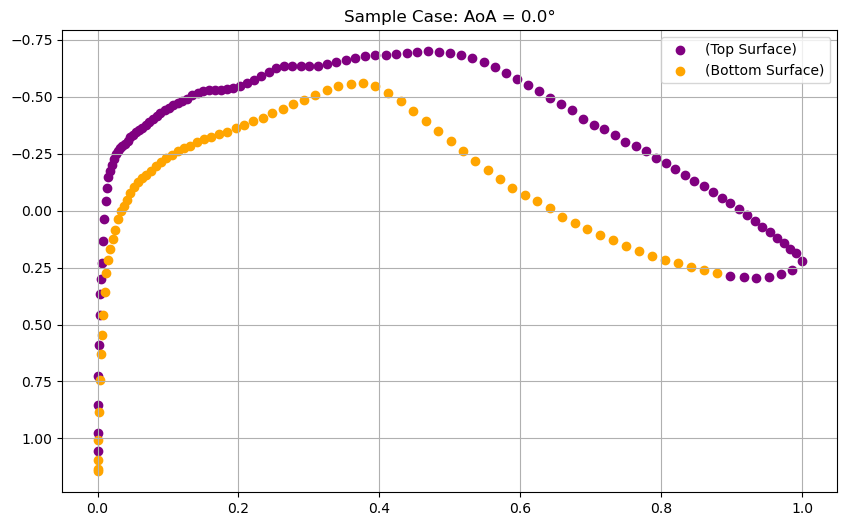

In [127]:
sample_case = full_data[full_data['AoA'] == 0.0]

plt.figure(figsize=(10, 6))
top_surface = sample_case[sample_case['y'] > 0].sort_values(by='x')
bottom_surface = sample_case[sample_case['y'] <= 0].sort_values(by='x')

plt.scatter(top_surface['x'], top_surface['Pressure_Coefficient'], color='purple', label='(Top Surface)')
plt.scatter(bottom_surface['x'], bottom_surface['Pressure_Coefficient'],color='orange', label='(Bottom Surface)')
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)
plt.title("Sample Case: AoA = 0.0°")

### Model Random Forest Regression

In [96]:
aoa_values = full_data['AoA'].unique()
features = ['x', 'y', 'AoA']
target = 'Pressure_Coefficient'


In [140]:
# Train test split Leave-one-out
# We only have 4000 row of data
# to prevent model cheating (Data Leakage) 
# we use leave-one-group-out cross validation
rdfr_model = RandomForestRegressor(n_estimators=300, random_state=42, oob_score=True)
scores = []
r2Scores = []

for aoa in aoa_values:
    train = full_data[full_data['AoA'] != aoa]
    test  = full_data[full_data['AoA'] == aoa]

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    rdfr_model.fit(X_train, y_train)
    prediction = rdfr_model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)
    scores.append(rmse)
    r2Scores.append(r2)

print("RMSE score: ", sum(scores)/len(scores))
print("R2 score: ", sum(r2Scores)/len(r2Scores))


RMSE score:  0.2250235632109718
R2 score:  0.6434255923906396


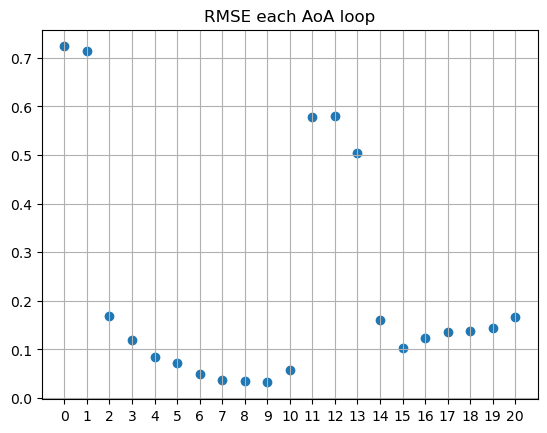

In [141]:
temp = range(21)
plt.scatter(temp, scores)
# plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.xticks(temp)
plt.grid(True)
plt.title("RMSE each AoA loop")
plt.show()

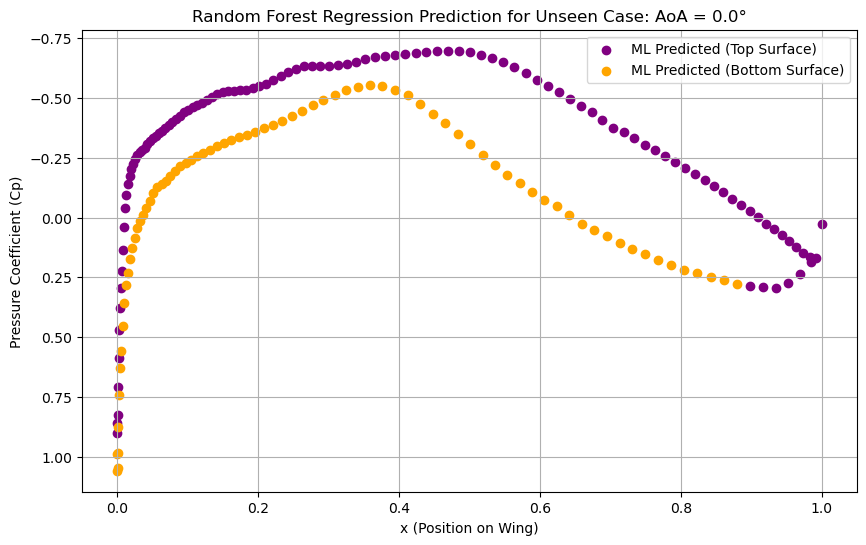

In [112]:
rdfr_model.fit(full_data[features], full_data[target])
new_case = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy()

new_case['AoA'] = 0.0

predicted_cp = rdfr_model.predict(new_case[['x', 'y', 'AoA']])

new_case['Predicted_Cp'] = predicted_cp

plt.figure(figsize=(10, 6))
top_surface = new_case[new_case['y'] > 0].sort_values(by='x')
bottom_surface = new_case[new_case['y'] <= 0].sort_values(by='x')

plt.scatter(top_surface['x'], top_surface['Predicted_Cp'], color='purple', linewidth=1, label='ML Predicted (Top Surface)')
plt.scatter(bottom_surface['x'], bottom_surface['Predicted_Cp'], color='orange', linewidth=1, label='ML Predicted (Bottom Surface)')

plt.gca().invert_yaxis() # Invert y-axis for Aerodynamics
plt.title("Random Forest Regression Prediction for Unseen Case: AoA = 0.0°")
plt.xlabel("x (Position on Wing)")
plt.ylabel("Pressure Coefficient (Cp)")
plt.legend()
plt.grid(True)
plt.show()

### Model Polynomial Regression

In [99]:
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("lin", LinearRegression())
])

scores = []
r2Scores = []

for aoa in aoa_values:
    train = full_data[full_data['AoA'] != aoa]
    test  = full_data[full_data['AoA'] == aoa]

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    poly_model.fit(X_train, y_train)

    prediction = poly_model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)
    scores.append(rmse)
    r2Scores.append(r2)

print("RMSE score: ", sum(scores)/len(scores))
print("R2 score: ", sum(r2Scores)/len(r2Scores))

RMSE score:  0.4510490763839333
R2 score:  0.4911929509831183


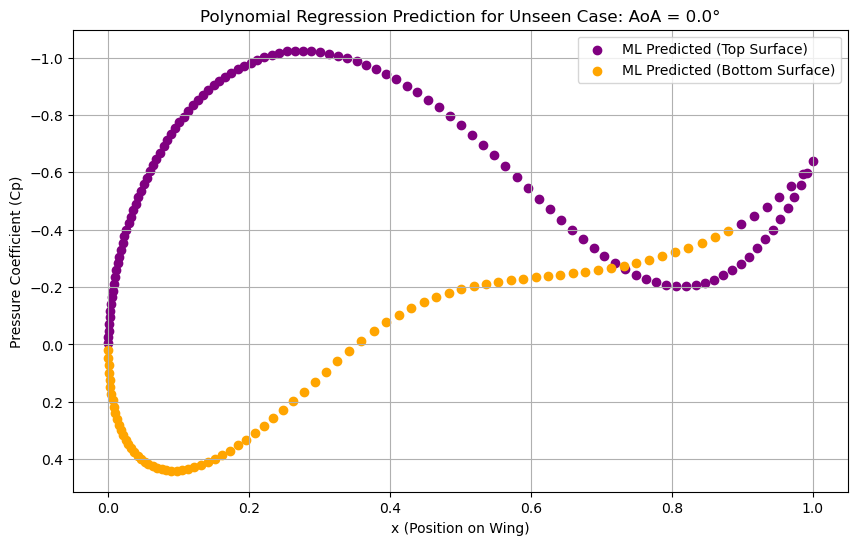

In [111]:
poly_model.fit(full_data[features], full_data[target])
new_case = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy()

new_case['AoA'] = 0.0

predicted_cp = poly_model.predict(new_case[['x', 'y', 'AoA']])

new_case['Predicted_Cp'] = predicted_cp

plt.figure(figsize=(10, 6))
top_surface = new_case[new_case['y'] > 0].sort_values(by='x')
bottom_surface = new_case[new_case['y'] <= 0].sort_values(by='x')

plt.scatter(top_surface['x'], top_surface['Predicted_Cp'], color='purple', linewidth=1, label='ML Predicted (Top Surface)')
plt.scatter(bottom_surface['x'], bottom_surface['Predicted_Cp'], color='orange', linewidth=1, label='ML Predicted (Bottom Surface)')

plt.gca().invert_yaxis() # Invert y-axis for Aerodynamics
plt.title("Polynomial Regression Prediction for Unseen Case: AoA = 0.0°")
plt.xlabel("x (Position on Wing)")
plt.ylabel("Pressure Coefficient (Cp)")
plt.legend()
plt.grid(True)
plt.show()

### Model Gradient Boosting

In [101]:
gbc = GradientBoostingRegressor(n_estimators=300,
                                 learning_rate=0.05,
                                 random_state=100,
                                 max_features=3 )

scores = []
r2Scores = []

for aoa in aoa_values:
    train = full_data[full_data['AoA'] != aoa]
    test  = full_data[full_data['AoA'] == aoa]

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    gbc.fit(X_train, y_train)
    prediction = gbc.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    r2 = r2_score(y_test, prediction)
    scores.append(rmse)
    r2Scores.append(r2)

print("RMSE score: ", sum(scores)/len(scores))
print("R2 score: ", sum(r2Scores)/len(r2Scores))
    

RMSE score:  0.22936433121972583
R2 score:  0.7028790935721196


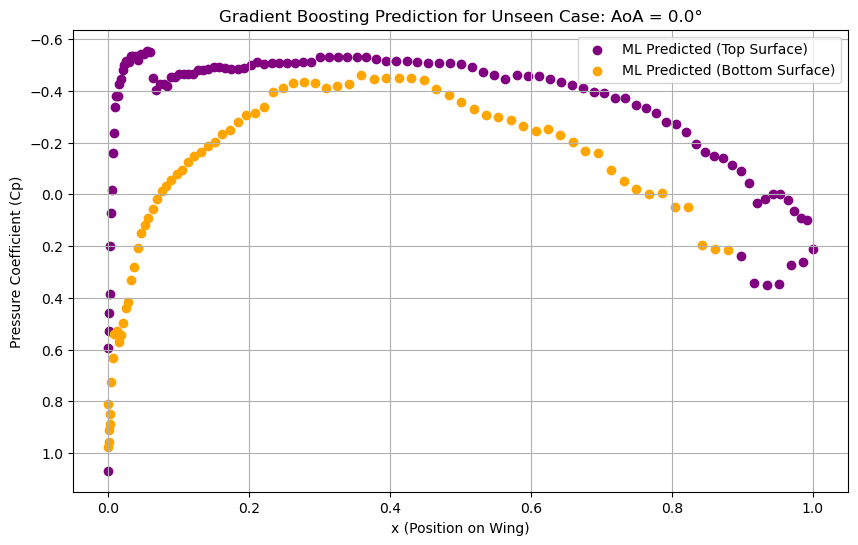

In [110]:
gbc.fit(full_data[features], full_data[target])
new_case = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy()

new_case['AoA'] = 0.0

predicted_cp = gbc.predict(new_case[['x', 'y', 'AoA']])

new_case['Predicted_Cp'] = predicted_cp

plt.figure(figsize=(10, 6))
top_surface = new_case[new_case['y'] > 0].sort_values(by='x')
bottom_surface = new_case[new_case['y'] <= 0].sort_values(by='x')

plt.scatter(top_surface['x'], top_surface['Predicted_Cp'], color='purple', linewidth=1, label='ML Predicted (Top Surface)')
plt.scatter(bottom_surface['x'], bottom_surface['Predicted_Cp'], color='orange', linewidth=1, label='ML Predicted (Bottom Surface)')

plt.gca().invert_yaxis() # Invert y-axis for Aerodynamics
plt.title("Gradient Boosting Prediction for Unseen Case: AoA = 0.0°")
plt.xlabel("x (Position on Wing)")
plt.ylabel("Pressure Coefficient (Cp)")
plt.legend()
plt.grid(True)
plt.show()